# 06 · Comparación de resoluciones

Compara tres modelos YOLOv8s entrenados a 640, 768 y 1024 px. Cada uno se evalúa
también a las tres resoluciones (nueve combinaciones), para separar el efecto
de la resolución de entrenamiento del de la resolución de inferencia. Todo se
hace sobre validación.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Compara YOLOv8s entrenado a 640, 768 y 1024 px, evaluando cada uno a las tres resoluciones. |
| **Cuándo abrirlo** | Para ver el estudio de resolución (Tablas 3 y 4 de la memoria). |
| **Comportamiento por defecto** | No recalcula (`RUN_COMPARISON=False`): muestra la última comparación guardada. |
| **Entradas principales** | Los tres entrenamientos de YOLOv8s y `configs/resolution_comparison.yaml`. |
| **Salidas principales** | `artifacts/06_resolution_comparison/`, con tablas, figuras y ejemplos. |
| **Continuación** | `08_DFire_optimizacion_hiperparametros_YOLO26s.ipynb` y `09_DFire_seleccion_final_validacion.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Volver a ejecutarlo requiere los resultados de los
> notebooks anteriores; ver `notebooks/README.md`.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

roots = [Path(os.environ["TFM_PROJECT_ROOT"])] if os.environ.get("TFM_PROJECT_ROOT") else []
roots += [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in roots if (p / "tfm_pipeline.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abrir el notebook dentro de TFM o definir TFM_PROJECT_ROOT.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import tfm_pipeline as pipeline

CONFIG_PATH = PROJECT_ROOT / "configs" / "resolution_comparison.yaml"
RUN_COMPARISON = False
RUN_ID = None


In [2]:
result_parent = PROJECT_ROOT / "artifacts" / "06_resolution_comparison" / "validation"
if RUN_COMPARISON:
    from tools.run_resolution_comparison import run
    RESULT_DIR = run(CONFIG_PATH)
elif RUN_ID:
    if Path(RUN_ID).name != RUN_ID:
        raise ValueError("RUN_ID debe ser un identificador, no una ruta.")
    RESULT_DIR = result_parent / RUN_ID
else:
    latest = pipeline.read_json(result_parent / "latest.json")
    RESULT_DIR = PROJECT_ROOT / latest["run_rel"]
    if pipeline.sha256_file(RESULT_DIR / "run_summary.json") != latest["summary_sha256"]:
        raise ValueError("El índice latest.json no coincide con el resumen.")

summary = pipeline.read_json(RESULT_DIR / "run_summary.json")
if summary["status"] != "complete" or summary["split"] != "val":
    raise ValueError("Se necesita una ejecución completa de validación.")
if summary["test_inference_executed"]:
    raise ValueError("Este análisis no debe utilizar test.")
for relative, expected in summary["output_hashes"].items():
    if pipeline.sha256_file(RESULT_DIR / relative) != expected:
        raise ValueError(f"Artefacto modificado: {relative}")

metrics = pd.read_csv(RESULT_DIR / "threshold_metrics.csv")
candidates = pd.read_csv(RESULT_DIR / "scenario_candidates.csv")
standard = pd.read_csv(RESULT_DIR / "standard_metrics.csv")
image_detection = pd.read_csv(RESULT_DIR / "image_detection_metrics.csv")
sizes = pd.read_csv(RESULT_DIR / "size_metrics.csv")
paired = pd.read_csv(RESULT_DIR / "paired_comparison.csv")
resources = pd.read_csv(RESULT_DIR / "training_resources.csv")
review = pd.read_csv(RESULT_DIR / "review_selection.csv")
error_summary = pd.read_csv(RESULT_DIR / "error_review_summary.csv")
error_examples = pd.read_csv(RESULT_DIR / "error_review_examples.csv")
selected = candidates[(candidates.scenario == "alarm_02pct") & candidates.feasible].copy()

variant_specs = summary["config"]["training_variants"]
ordered_variants = sorted(variant_specs, key=lambda v: int(variant_specs[v]["trained_imgsz"]))
native_keys = [f"{v}_eval{int(variant_specs[v]['trained_imgsz'])}" for v in ordered_variants]
labels = {
    f"{variant}_eval{eval_size}": (
        f"Entrena {int(variant_specs[variant]['trained_imgsz'])} → evalúa {int(eval_size)}"
    )
    for variant in ordered_variants
    for eval_size in summary["config"]["evaluation_sizes"]
}
operating = selected.merge(
    image_detection,
    left_on=["model_key", "threshold"],
    right_on=["configuration", "threshold"],
    validate="one_to_one",
)
native = operating[operating.model_key.isin(native_keys)].set_index("model_key").loc[native_keys]
print(f"Ejecución: {summary['run_id']} · {summary['images_per_configuration']:,} imágenes por configuración")
print(f"Dataset: {summary['dataset_version']} · test consultado: {summary['test_inference_executed']}")
print(f"Resultados: {RESULT_DIR}")


Ejecución: 20260912T150556Z_f0565f74 · 1,721 imágenes por configuración
Dataset: dfire_seed42_val10_v1 · test consultado: False
Resultados: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74


## Resumen

In [3]:
baseline_key = native_keys[0]
focus_key = f"{summary['config']['focus_variant']}_eval{int(summary['config']['focus_evaluation_size'])}"
best_recall_key = native.fire_recall.idxmax()
best_f1_key = native.micro_f1.idxmax()
base = native.loc[baseline_key]
focus = operating.set_index("model_key").loc[focus_key]
base_std = standard[(standard.configuration == baseline_key) & (standard.scope == "fire")].iloc[0]
focus_std = standard[(standard.configuration == focus_key) & (standard.scope == "fire")].iloc[0]
focus_variant = focus_key.rsplit("_eval", 1)[0]
focus_cost = resources.set_index("variant").loc[focus_variant, "training_time_ratio_vs_640"]

display(Markdown(f"""El modelo entrenado a **768** e inferido a **640** obtiene
**{focus.fire_recall:.1%} de recall de fuego**
y **{focus.micro_f1:.1%} de F1 micro** en su punto operativo, frente a
**{base.fire_recall:.1%}** y **{base.micro_f1:.1%}** a 640. El cambio es
**{focus.fire_recall-base.fire_recall:+.1%}** en recall y
**{focus.micro_f1-base.micro_f1:+.1%}** en F1, con
**{int(focus.negative_images_with_alarm)}/783** negativas con alarma.

El mAP50-95 estándar de fuego cambia de **{base_std.mAP50_95:.3f}** a
**{focus_std.mAP50_95:.3f}** y entrenar a 768 costó **{focus_cost:.2f}×** respecto
a 640. El mayor recall nativo lo consigue **{labels[best_recall_key]}** y el mayor
F1 nativo **{labels[best_f1_key]}**. La decisión se toma con estas métricas y el
coste, no con una sola cifra."""))


El modelo entrenado a **768** e inferido a **640** obtiene
**73.2% de recall de fuego**
y **75.7% de F1 micro** en su punto operativo, frente a
**70.5%** y **75.2%** a 640. El cambio es
**+2.7%** en recall y
**+0.5%** en F1, con
**13/783** negativas con alarma.

El mAP50-95 estándar de fuego cambia de **0.392** a
**0.396** y entrenar a 768 costó **1.44×** respecto
a 640. El mayor recall nativo lo consigue **Entrena 1024 → evalúa 1024** y el mayor
F1 nativo **Entrena 640 → evalúa 640**. La decisión se toma con estas métricas y el
coste, no con una sola cifra.

## Método

- Las nueve combinaciones se evalúan sobre las mismas 1.721 imágenes de
  validación.
- Para cada una se prueban 21 umbrales y se elige el que da mayor recall medio
  de humo y fuego con, como máximo, un 2 % de imágenes sin humo ni fuego con
  alarma (15 de 783).
- Una detección es correcta si es de la misma clase y solapa al menos un 50 %
  con la caja real.
- También se mide el recall de fuego por tamaño de caja y el tiempo de
  inferencia.
- Hay un solo entrenamiento (una semilla) por resolución.

## Cada modelo a su propia resolución

,Umbral,Recall humo,Recall fuego,Recall imágenes con fuego,Precisión micro,F1 micro,Negativas con alarma,Tasa de alarma
Configuración,,,,,,,,
Entrena 640 → evalúa 640,0.30,82.1%,70.5%,88.5%,74.7%,75.2%,13,1.66%
Entrena 768 → evalúa 768,0.30,81.0%,71.2%,90.9%,73.5%,74.5%,15,1.92%
Entrena 1024 → evalúa 1024,0.25,83.5%,73.5%,91.1%,70.7%,74.2%,14,1.79%


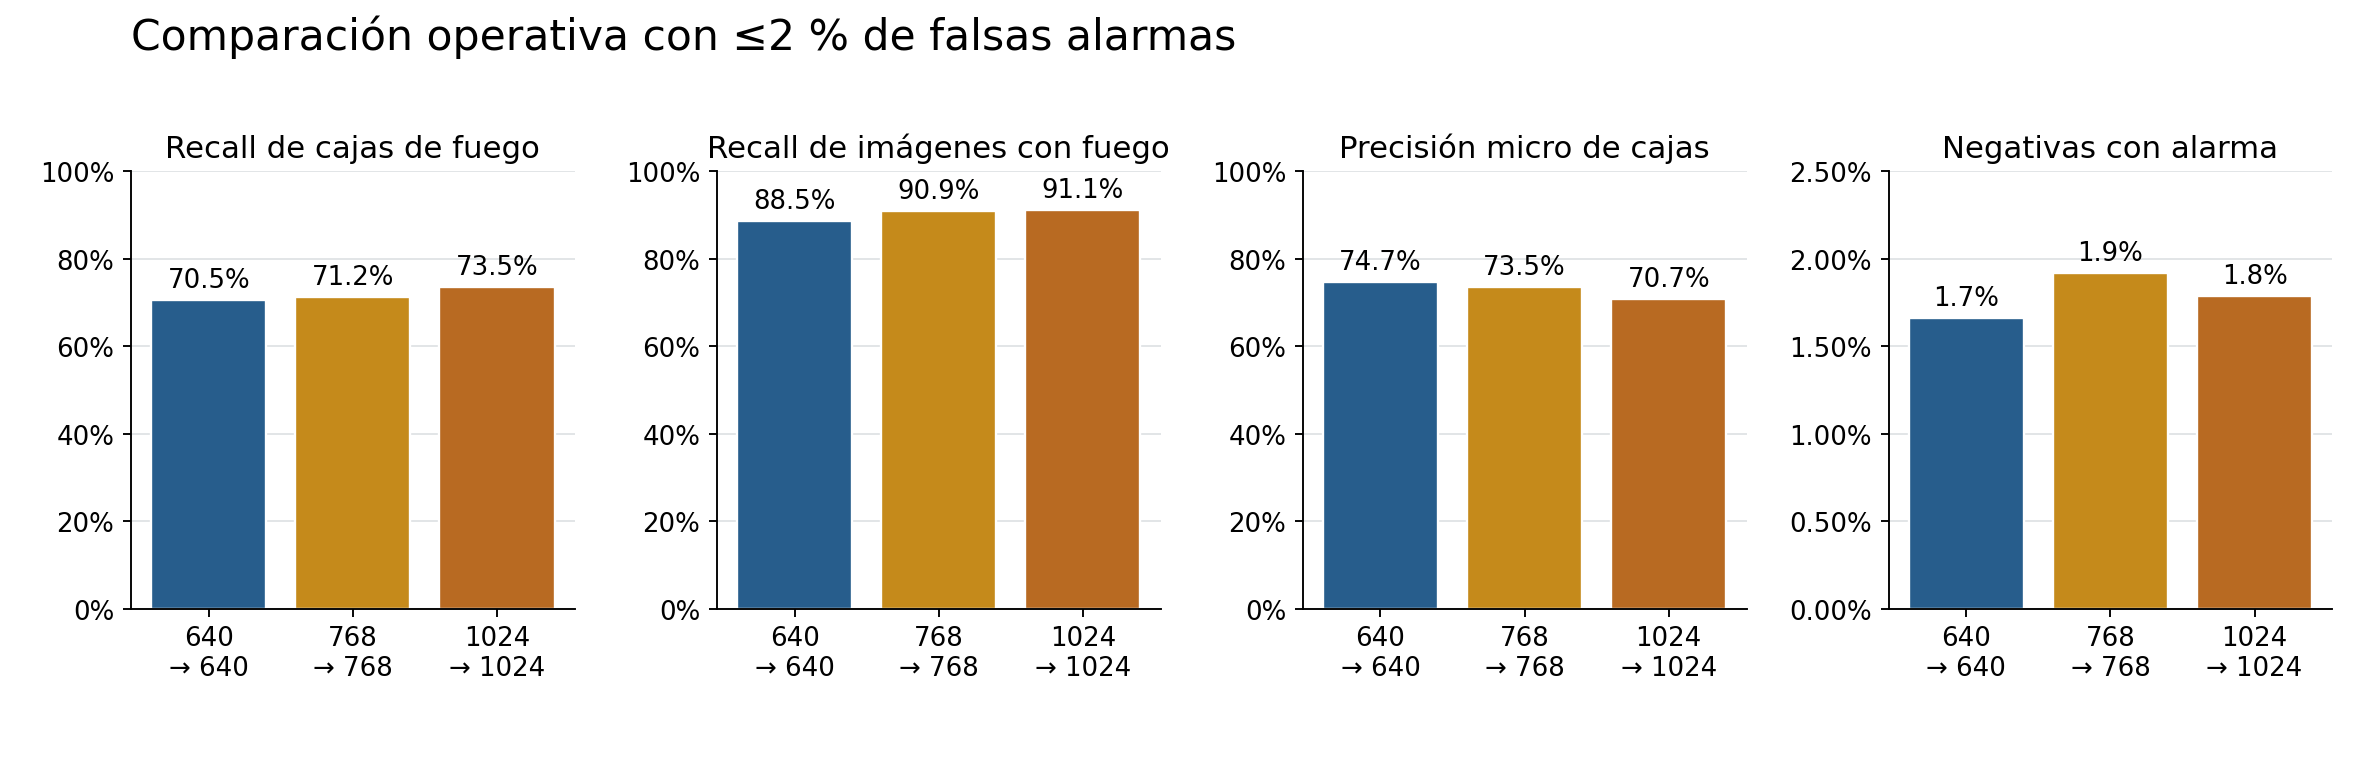

In [4]:
native_table = native[[
    "threshold", "smoke_recall", "fire_recall", "fire_image_recall",
    "micro_precision", "micro_f1", "negative_images_with_alarm", "negative_alarm_rate"
]].copy()
native_table.index = [labels[key] for key in native_table.index]
native_table.index.name = "Configuración"
native_table.columns = [
    "Umbral", "Recall humo", "Recall fuego", "Recall imágenes con fuego",
    "Precisión micro", "F1 micro", "Negativas con alarma", "Tasa de alarma",
]
display(native_table.style.format({
    "Umbral": "{:.2f}", "Recall humo": "{:.1%}", "Recall fuego": "{:.1%}",
    "Recall imágenes con fuego": "{:.1%}", "Precisión micro": "{:.1%}",
    "F1 micro": "{:.1%}", "Negativas con alarma": "{:.0f}", "Tasa de alarma": "{:.2%}",
}))
display(Image(filename=str(RESULT_DIR / "figures" / "01_native_operating_comparison.png"), width=1100,
              alt="Comparación operativa nativa a 640, 768 y 1024"))


## Las nueve combinaciones

Configuración,Umbral,Recall humo,Recall fuego,Recall imágenes con fuego,Precisión micro,F1 micro,Negativas con alarma,Tasa de alarma
Entrena 1024 → evalúa 640,0.20,83.4%,74.9%,92.8%,66.6%,72.2%,14,1.79%
Entrena 1024 → evalúa 1024,0.25,83.5%,73.5%,91.1%,70.7%,74.2%,14,1.79%
Entrena 768 → evalúa 640,0.30,80.9%,73.2%,92.6%,74.6%,75.7%,13,1.66%
Entrena 1024 → evalúa 768,0.25,82.4%,72.7%,90.4%,71.1%,74.0%,14,1.79%
Entrena 640 → evalúa 768,0.30,81.1%,71.5%,89.1%,73.8%,74.8%,11,1.40%
Entrena 768 → evalúa 768,0.30,81.0%,71.2%,90.9%,73.5%,74.5%,15,1.92%
Entrena 640 → evalúa 640,0.30,82.1%,70.5%,88.5%,74.7%,75.2%,13,1.66%
Entrena 768 → evalúa 1024,0.35,79.9%,68.7%,89.4%,69.7%,71.7%,15,1.92%
Entrena 640 → evalúa 1024,0.40,70.7%,63.4%,85.3%,75.5%,70.8%,12,1.53%


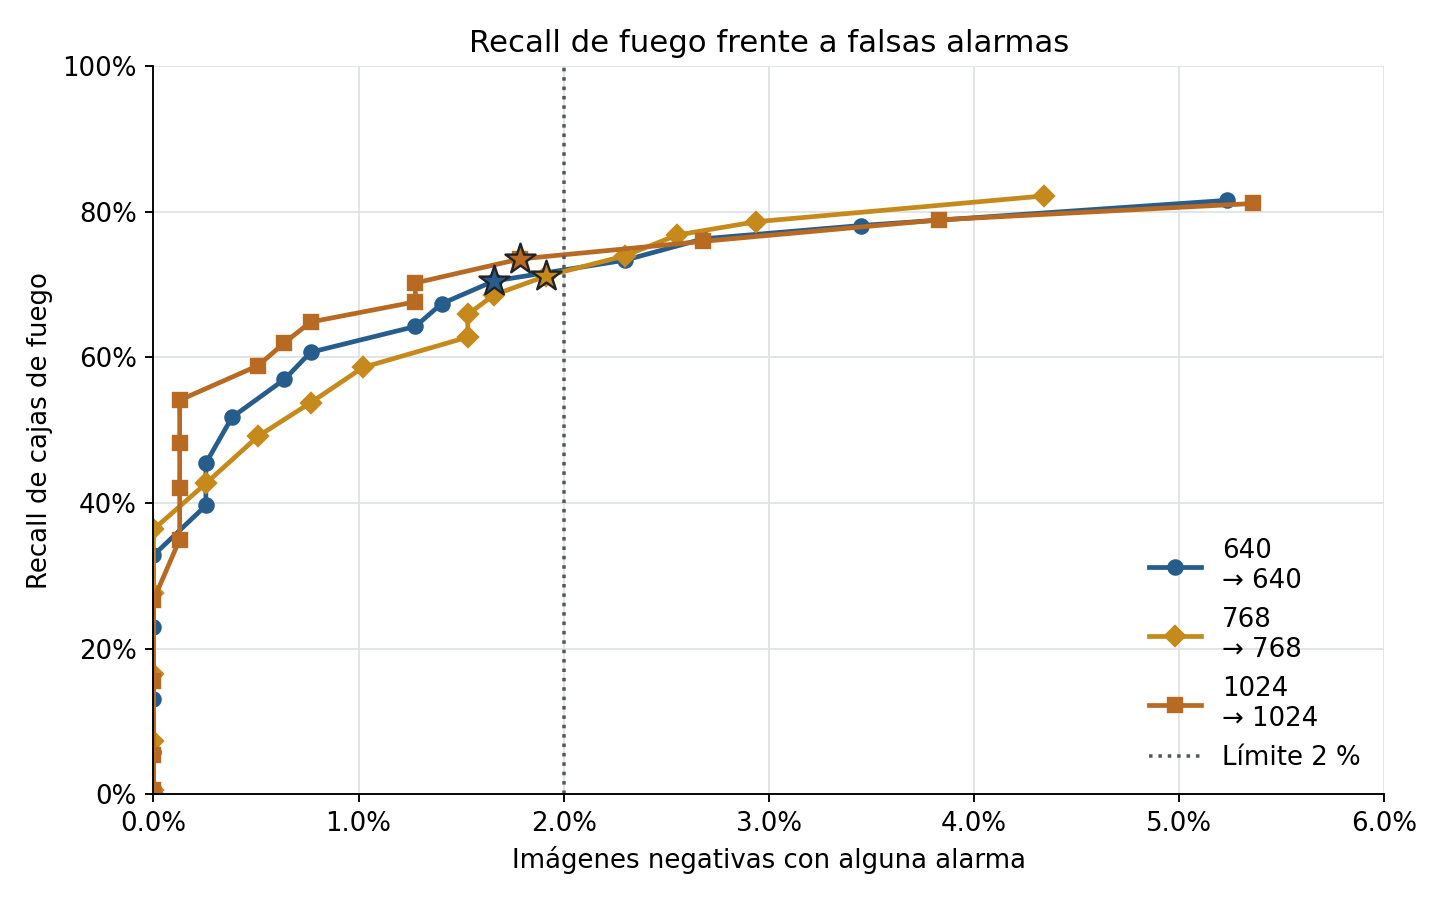

In [5]:
all_operating = operating[[
    "model_key", "threshold", "smoke_recall", "fire_recall", "fire_image_recall",
    "micro_precision", "micro_f1", "negative_images_with_alarm", "negative_alarm_rate"
]].copy()
all_operating["model_key"] = all_operating.model_key.map(labels)
all_operating = all_operating.sort_values(["fire_recall", "micro_f1"], ascending=False)
all_operating.columns = [
    "Configuración", "Umbral", "Recall humo", "Recall fuego", "Recall imágenes con fuego",
    "Precisión micro", "F1 micro", "Negativas con alarma", "Tasa de alarma",
]
display(all_operating.style.format({
    "Umbral": "{:.2f}", "Recall humo": "{:.1%}", "Recall fuego": "{:.1%}",
    "Recall imágenes con fuego": "{:.1%}", "Precisión micro": "{:.1%}",
    "F1 micro": "{:.1%}", "Negativas con alarma": "{:.0f}", "Tasa de alarma": "{:.2%}",
}).hide(axis="index"))
display(Image(filename=str(RESULT_DIR / "figures" / "02_fire_tradeoff.png"), width=850,
              alt="Recall de fuego frente a falsas alarmas"))


## Métricas estándar y tiempo de inferencia

Configuración,Precisión,Recall,mAP50,mAP50-95,Inferencia ms/imagen,Pico CUDA GiB
Entrena 640 → evalúa 640,74.7%,65.8%,72.9%,39.2%,1.72,0.35
Entrena 640 → evalúa 768,74.0%,67.4%,73.2%,39.2%,2.17,0.51
Entrena 640 → evalúa 1024,71.6%,63.9%,71.3%,36.1%,4.19,0.81
Entrena 768 → evalúa 640,76.9%,68.7%,75.2%,39.6%,1.66,0.35
Entrena 768 → evalúa 768,75.0%,66.1%,74.8%,39.8%,2.22,0.51
Entrena 768 → evalúa 1024,71.7%,67.1%,71.9%,37.6%,4.12,0.81
Entrena 1024 → evalúa 640,75.6%,65.8%,73.8%,38.9%,1.70,0.35
Entrena 1024 → evalúa 768,75.6%,66.1%,74.7%,40.1%,2.14,0.51
Entrena 1024 → evalúa 1024,75.4%,68.3%,74.3%,39.2%,4.11,0.81


Entrenamiento,imgsz,Épocas,Mejor época,Horas,Mejor mAP50-95,Coste relativo
train640,640,97,77,2.70,0.4652,1.00×
train768,768,100,89,3.88,0.4662,1.44×
train1024,1024,97,77,6.79,0.4568,2.51×


Los tiempos de inferencia proceden de val con batch=8 y sirven como comparación relativa.


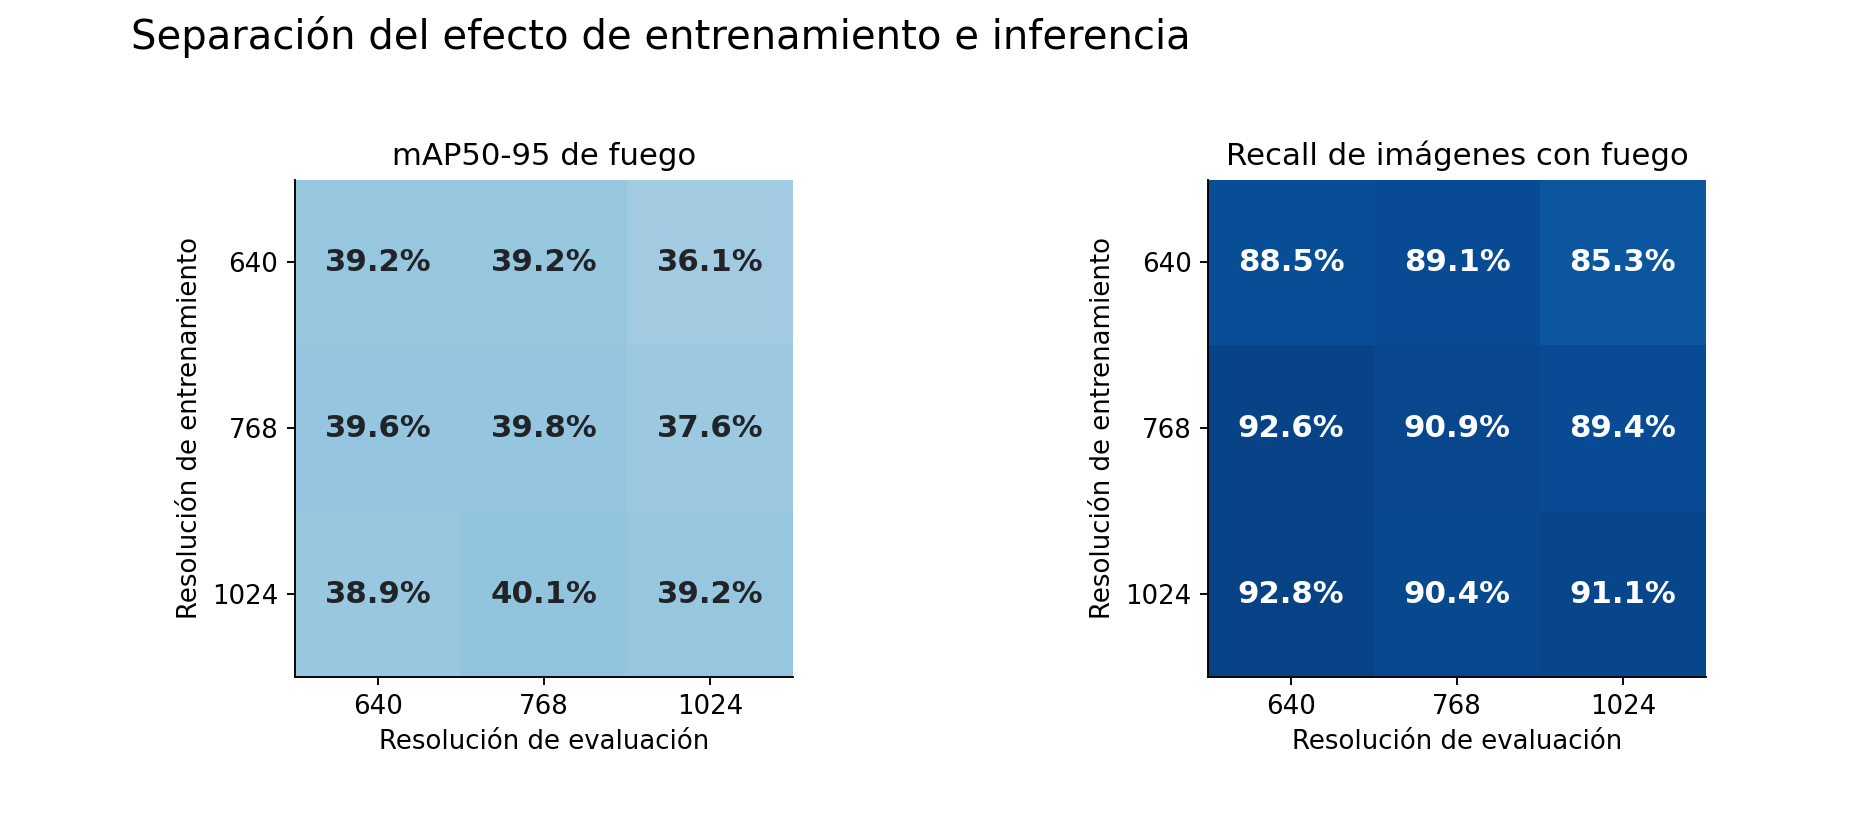

In [6]:
std_fire = standard[standard.scope == "fire"][[
    "configuration", "precision", "recall", "mAP50", "mAP50_95",
    "inference_ms", "peak_cuda_allocated_gib"
]].copy()
std_fire["configuration"] = std_fire.configuration.map(labels)
std_fire.columns = [
    "Configuración", "Precisión", "Recall", "mAP50", "mAP50-95",
    "Inferencia ms/imagen", "Pico CUDA GiB",
]
display(std_fire.style.format({
    "Precisión": "{:.1%}", "Recall": "{:.1%}", "mAP50": "{:.1%}", "mAP50-95": "{:.1%}",
    "Inferencia ms/imagen": "{:.2f}", "Pico CUDA GiB": "{:.2f}",
}).hide(axis="index"))
display(resources.rename(columns={
    "variant": "Entrenamiento", "trained_imgsz": "imgsz", "epochs_completed": "Épocas",
    "best_epoch": "Mejor época", "training_hours": "Horas",
    "best_training_map50_95": "Mejor mAP50-95", "training_time_ratio_vs_640": "Coste relativo",
})[["Entrenamiento", "imgsz", "Épocas", "Mejor época", "Horas", "Mejor mAP50-95", "Coste relativo"]]
 .style.format({"Horas": "{:.2f}", "Mejor mAP50-95": "{:.4f}", "Coste relativo": "{:.2f}×"})
 .hide(axis="index"))
print("Los tiempos de inferencia proceden de val con batch=8 y sirven como comparación relativa.")
display(Image(filename=str(RESULT_DIR / "figures" / "03_factorial_resolution.png"), width=1000,
              alt="Matrices de resolución de entrenamiento e inferencia"))


## Fuego por tamaño de caja y comparación con 640 px

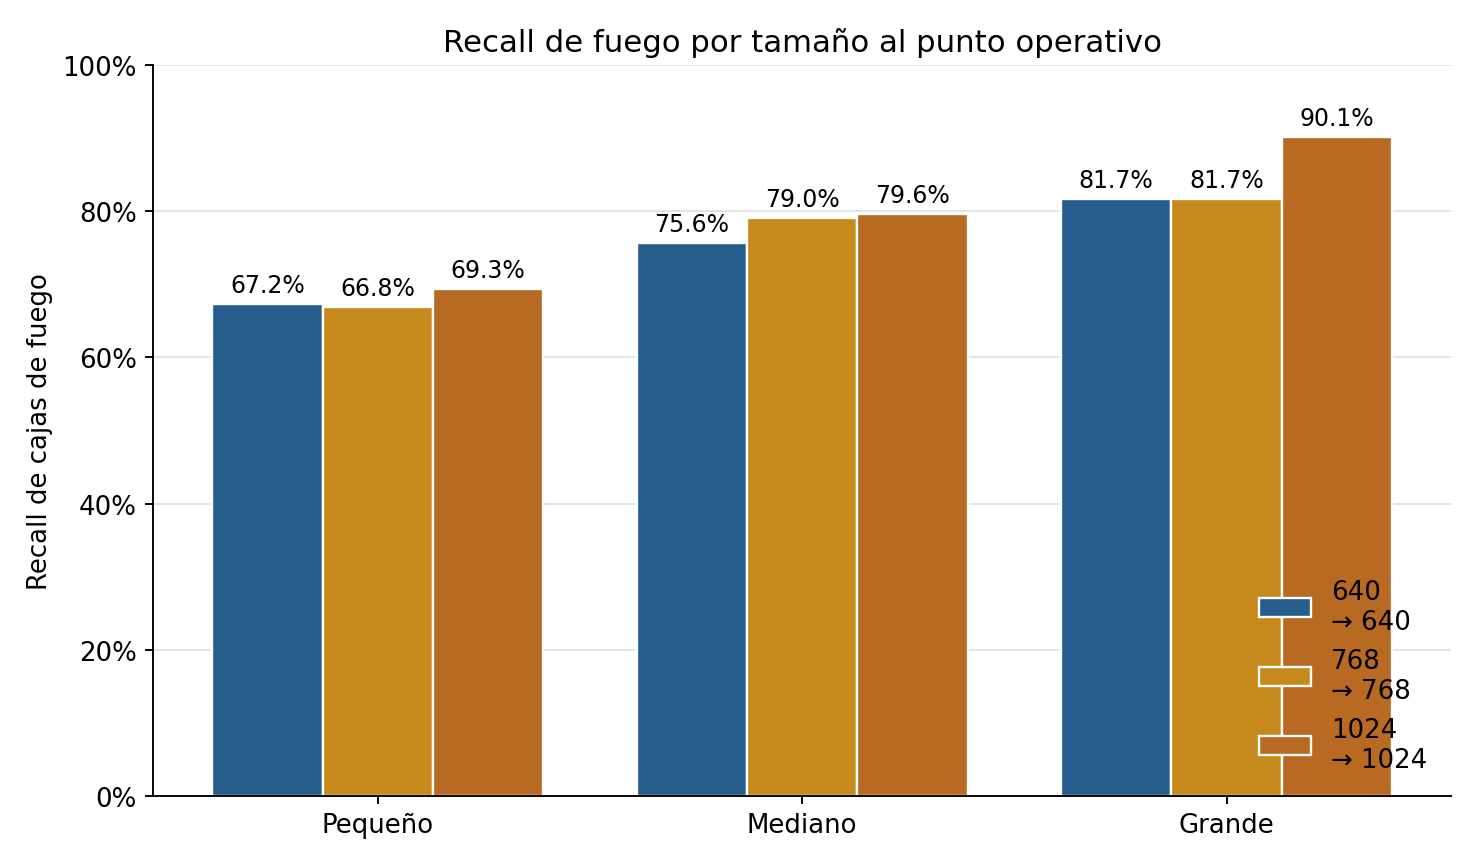

,Entrena 640 → evalúa 640,Entrena 768 → evalúa 768,Entrena 1024 → evalúa 1024
Pequeño (<1 %),67.2%,66.8%,69.3%
Mediano (1–10 %),75.6%,79.0%,79.6%
Grande (≥10 %),81.7%,81.7%,90.1%


Candidato,Unidad,n,Recuperaciones,Pérdidas,Tasa 640,Tasa candidato,p exacta
Entrena 1024 → evalúa 1024,Imagen con fuego,470,24,12,88.5%,91.1%,0.0652
Entrena 1024 → evalúa 1024,Caja de fuego,1155,99,64,70.5%,73.5%,0.0076
Entrena 768 → evalúa 640,Imagen con fuego,470,23,4,88.5%,92.6%,0.0003
Entrena 768 → evalúa 640,Caja de fuego,1155,78,47,70.5%,73.2%,0.0070
Entrena 768 → evalúa 768,Imagen con fuego,470,17,6,88.5%,90.9%,0.0347
Entrena 768 → evalúa 768,Caja de fuego,1155,68,60,70.5%,71.2%,0.5363


In [7]:
display(Image(filename=str(RESULT_DIR / "figures" / "04_fire_recall_by_size.png"), width=850,
              alt="Recall de fuego por tamaño de caja"))
picks = native.threshold.to_dict()
size_native = pd.concat([
    sizes[
        (sizes.model_key == key)
        & np.isclose(sizes.threshold, threshold)
        & (sizes.class_name == "fire")
    ]
    for key, threshold in picks.items()
])
size_table = size_native.pivot(index="size_band", columns="model_key", values="recall")
size_table = size_table.loc[["small", "medium", "large"], native_keys]
size_table.index = ["Pequeño (<1 %)", "Mediano (1–10 %)", "Grande (≥10 %)"]
size_table.columns = [labels[key] for key in native_keys]
display(size_table.style.format("{:.1%}"))

reported_pair_keys = set(native_keys[1:] + [focus_key])
paired_view = paired[paired.candidate_key.isin(reported_pair_keys)].copy()
paired_view["Candidato"] = paired_view.candidate_key.map(labels)
paired_view["Unidad"] = paired_view.unit.map({
    "fire_positive_image": "Imagen con fuego", "fire_box": "Caja de fuego"
})
paired_view = paired_view[[
    "Candidato", "Unidad", "n", "gains", "losses",
    "baseline_rate", "candidate_rate", "p_value"
]]
paired_view.columns = [
    "Candidato", "Unidad", "n", "Recuperaciones", "Pérdidas",
    "Tasa 640", "Tasa candidato", "p exacta",
]
display(paired_view.style.format({
    "Tasa 640": "{:.1%}", "Tasa candidato": "{:.1%}", "p exacta": "{:.4f}",
}).hide(axis="index"))


## Ejemplos con inferencia a 640 px

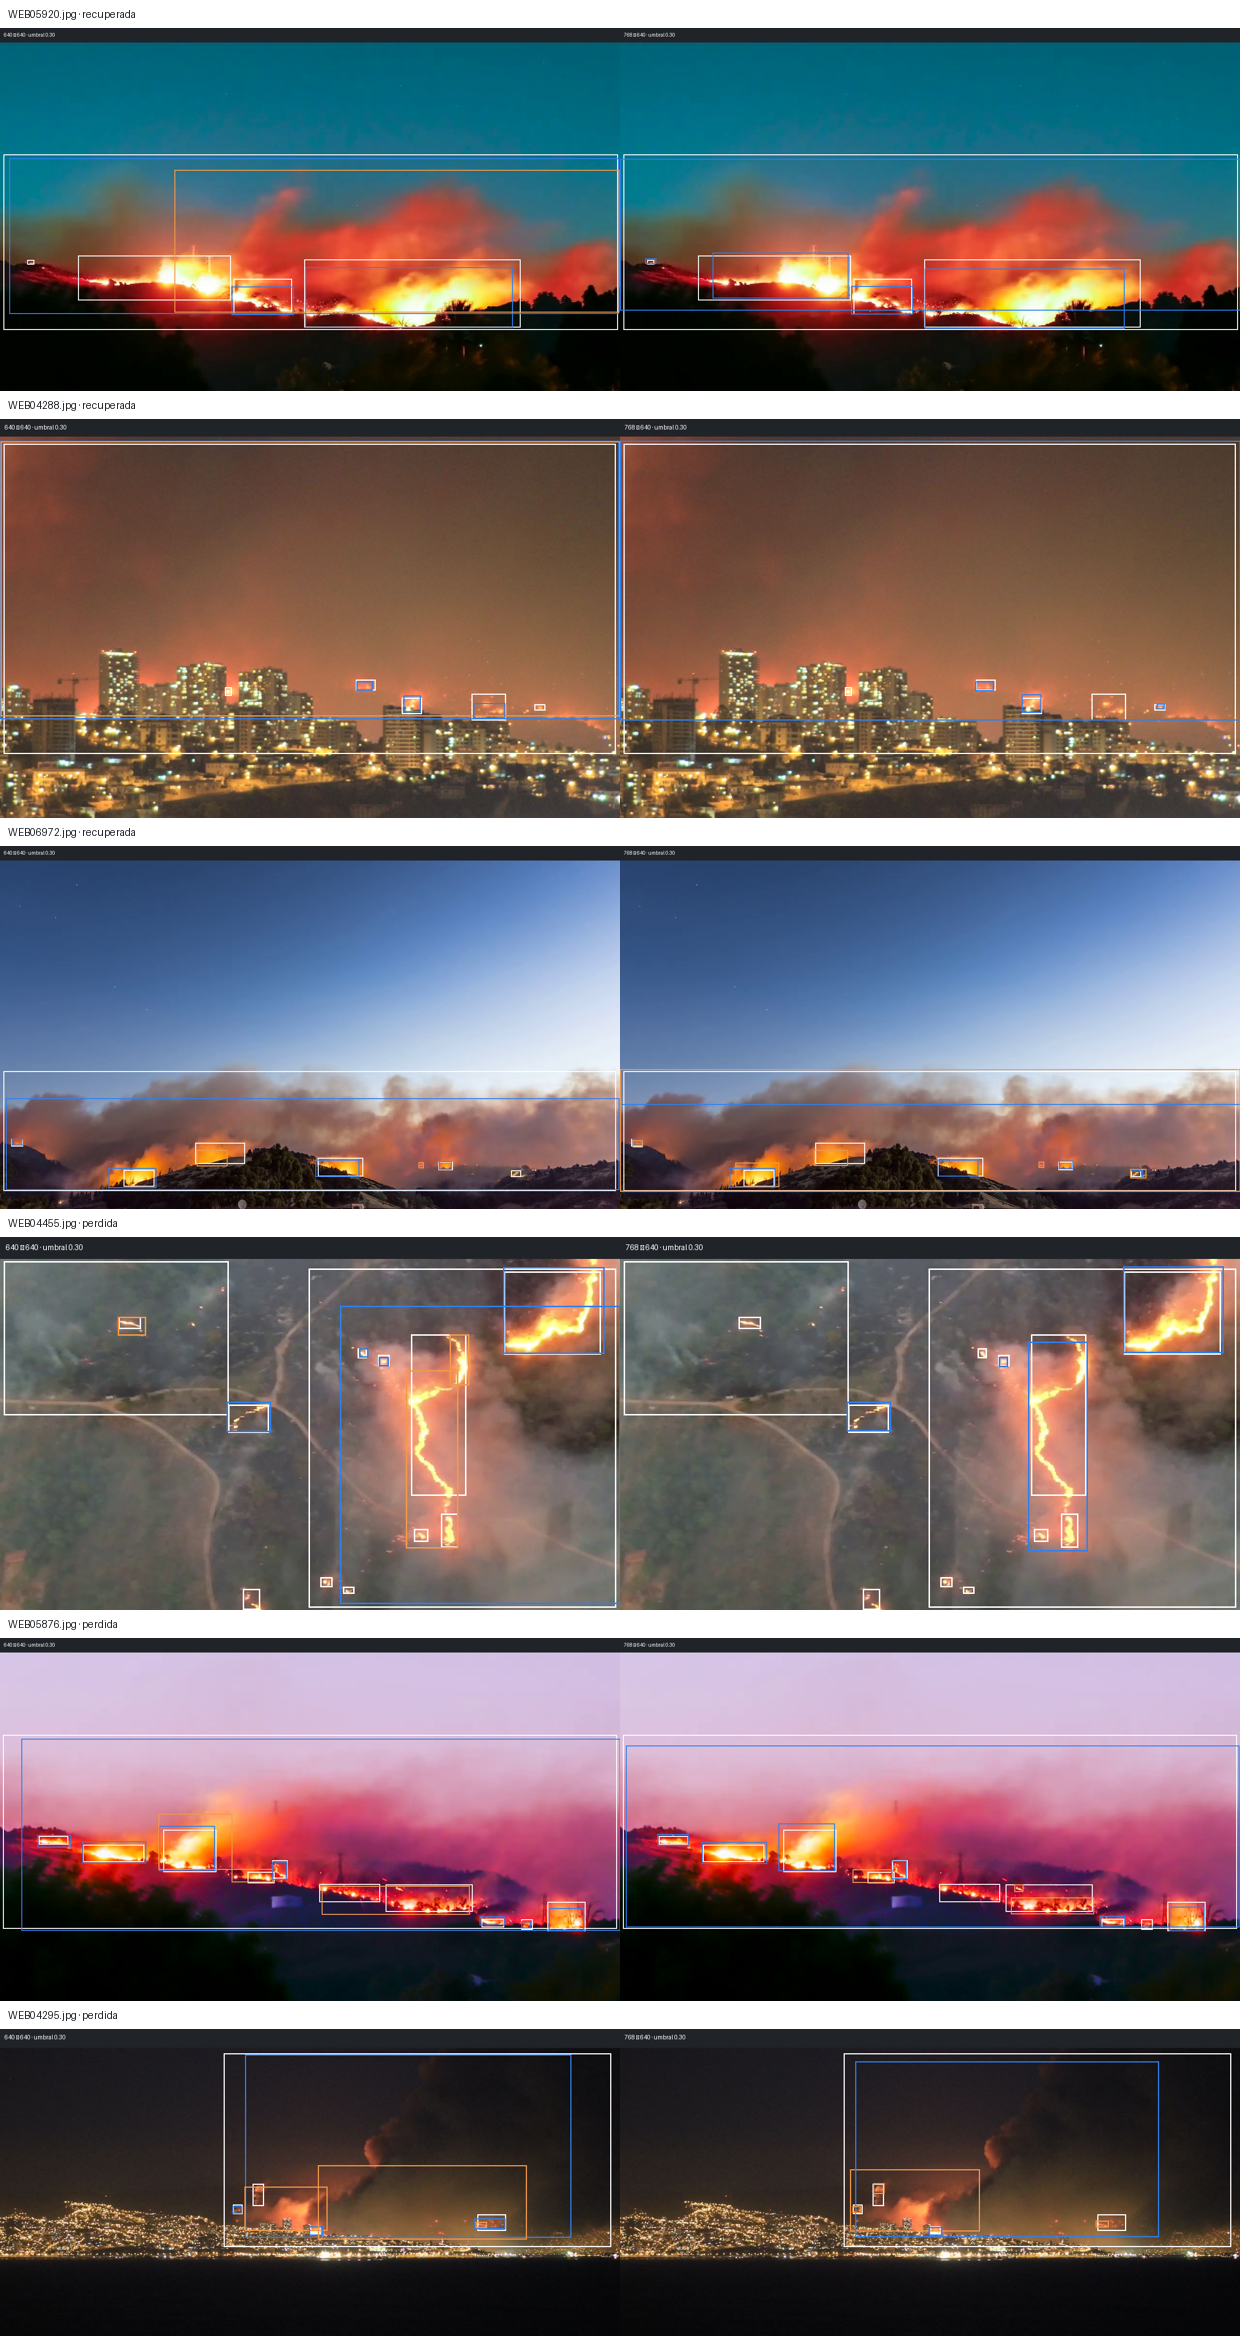

Imagen,Fracción de área,Tamaño,Cambio,640 → 640,768 → 640
WEB05920.jpg,0.014%,small,recuperada,fn,tp
WEB04288.jpg,0.026%,small,recuperada,fn,tp
WEB06972.jpg,0.028%,small,recuperada,fn,tp
WEB04455.jpg,0.042%,small,perdida,tp,fn
WEB05876.jpg,0.052%,small,perdida,tp,fn
WEB04295.jpg,0.054%,small,perdida,tp,fn


In [8]:
display(Image(filename=str(RESULT_DIR / "figures" / "05_changed_fire_examples.png"), width=1100,
              alt="Ejemplos de detecciones de fuego que cambian al entrenar a 768"))
review_view = review.rename(columns={
    "filename": "Imagen", "area_fraction": "Fracción de área", "size_band": "Tamaño",
    "change": "Cambio", "status_baseline": "640 → 640", "status_candidate": "768 → 640",
})
display(review_view[["Imagen", "Fracción de área", "Tamaño", "Cambio", "640 → 640", "768 → 640"]]
        .style.format({"Fracción de área": "{:.3%}"}).hide(axis="index"))


Blanco: caja real. Azul: detección correcta. Naranja: detección incorrecta.
Ejemplos elegidos para entender errores concretos, no para medir su frecuencia.

## Tipos de error

In [9]:
review_error_keys = list(dict.fromkeys(native_keys + [focus_key]))
native_errors = error_summary[error_summary.configuration.isin(review_error_keys)].copy()
native_errors["configuration"] = native_errors.configuration.map(labels)
native_errors.columns = [
    "Configuración", "Umbral", "FN humo", "FN fuego", "FP humo", "FP fuego",
    "FP en negativas", "FP en positivas", "Negativas con alarma",
    "Positivas con FP", "Imágenes de fuego perdidas", "Imágenes de incidente perdidas",
]
display(native_errors.style.format({"Umbral": "{:.2f}"}).hide(axis="index"))
display(error_examples.head(15).rename(columns={
    "filename": "Imagen", "category": "Categoría", "gt_count": "Cajas GT",
    "pred_count": "Predicciones", "smoke_tp": "TP humo", "fire_tp": "TP fuego",
    "smoke_fp": "FP humo", "fire_fp": "FP fuego", "smoke_fn": "FN humo",
    "fire_fn": "FN fuego", "error_priority": "Errores",
})[["Imagen", "Categoría", "Cajas GT", "Predicciones", "TP humo", "TP fuego",
    "FP humo", "FP fuego", "FN humo", "FN fuego", "Errores"]]
 .style.hide(axis="index"))


Configuración,Umbral,FN humo,FN fuego,FP humo,FP fuego,FP en negativas,FP en positivas,Negativas con alarma,Positivas con FP,Imágenes de fuego perdidas,Imágenes de incidente perdidas
Entrena 640 → evalúa 640,0.30,172,341,181,363,19,525,13,315,54,75
Entrena 768 → evalúa 640,0.30,183,310,190,361,14,537,13,318,35,78
Entrena 768 → evalúa 768,0.30,182,333,202,376,15,563,15,335,43,80
Entrena 1024 → evalúa 1024,0.25,158,306,242,442,15,669,14,377,42,61


Imagen,Categoría,Cajas GT,Predicciones,TP humo,TP fuego,FP humo,FP fuego,FN humo,FN fuego,Errores
WEB04337.jpg,smoke+fire,9,6,0,0,1,5,1,8,15
WEB05734.jpg,smoke+fire,13,13,0,7,0,6,1,5,12
WEB05832.jpg,smoke+fire,9,7,1,2,1,3,0,6,10
WEB04455.jpg,smoke+fire,13,4,0,4,0,0,2,7,9
WEB04627.jpg,fire,5,4,0,0,1,3,0,5,9
WEB04811.jpg,smoke+fire,10,3,0,2,0,1,3,5,9
WEB04378.jpg,smoke+fire,5,4,0,0,1,3,2,3,9
WEB06747.jpg,smoke+fire,5,12,2,2,0,8,0,1,9
WEB04196.jpg,smoke+fire,6,6,1,1,0,4,0,4,8
WEB04301.jpg,smoke+fire,3,9,1,1,0,7,0,1,8


## Conclusiones

In [10]:
focus_pair = paired[paired.candidate_key == focus_key].set_index("unit")
display(Markdown(f"""Frente a 640 → 640, el modelo 768 → 640 recupera
**{int(focus_pair.loc['fire_box', 'gains'])}** cajas de fuego y pierde
**{int(focus_pair.loc['fire_box', 'losses'])}**; en imágenes con fuego recupera
**{int(focus_pair.loc['fire_positive_image', 'gains'])}** y pierde
**{int(focus_pair.loc['fire_positive_image', 'losses'])}**.

La evaluación permite decidir la resolución de referencia y el punto operativo
en validación. No demuestra variabilidad entre entrenamientos porque se ha usado
una sola semilla, ni mide todavía falsas alarmas por minuto en vídeo. El umbral
elegido debe congelarse antes de consultar test."""))


Frente a 640 → 640, el modelo 768 → 640 recupera
**78** cajas de fuego y pierde
**47**; en imágenes con fuego recupera
**23** y pierde
**4**.

La evaluación permite decidir la resolución de referencia y el punto operativo
en validación. No demuestra variabilidad entre entrenamientos porque se ha usado
una sola semilla, ni mide todavía falsas alarmas por minuto en vídeo. El umbral
elegido debe congelarse antes de consultar test.

## Ficheros de la comparación

In [11]:
print("Configuración:", RESULT_DIR / "config.yaml")
print("Resumen narrativo:", RESULT_DIR / "RESUMEN_RESOLUCION.md")
print("Barrido completo:", RESULT_DIR / "threshold_metrics.csv")
print("Métricas estándar:", RESULT_DIR / "standard_metrics.csv")
print("Comparación emparejada:", RESULT_DIR / "paired_comparison.csv")
print("Resumen de errores:", RESULT_DIR / "error_review_summary.csv")
print("Casos prioritarios:", RESULT_DIR / "error_review_examples.csv")
print("Código ejecutado fijado en:", RESULT_DIR / "code")
print("Verificación independiente: python tools/verify_resolution_comparison.py")
print("Reconstruir notebook: python tools/build_resolution_notebook.py")


Configuración: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/config.yaml
Resumen narrativo: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/RESUMEN_RESOLUCION.md
Barrido completo: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/threshold_metrics.csv
Métricas estándar: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/standard_metrics.csv
Comparación emparejada: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/paired_comparison.csv
Resumen de errores: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/error_review_summary.csv
Casos prioritarios: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_f0565f74/error_review_examples.csv
Código ejecutado fijado en: /workspace/TFM/artifacts/06_resolution_comparison/validation/20260912T150556Z_